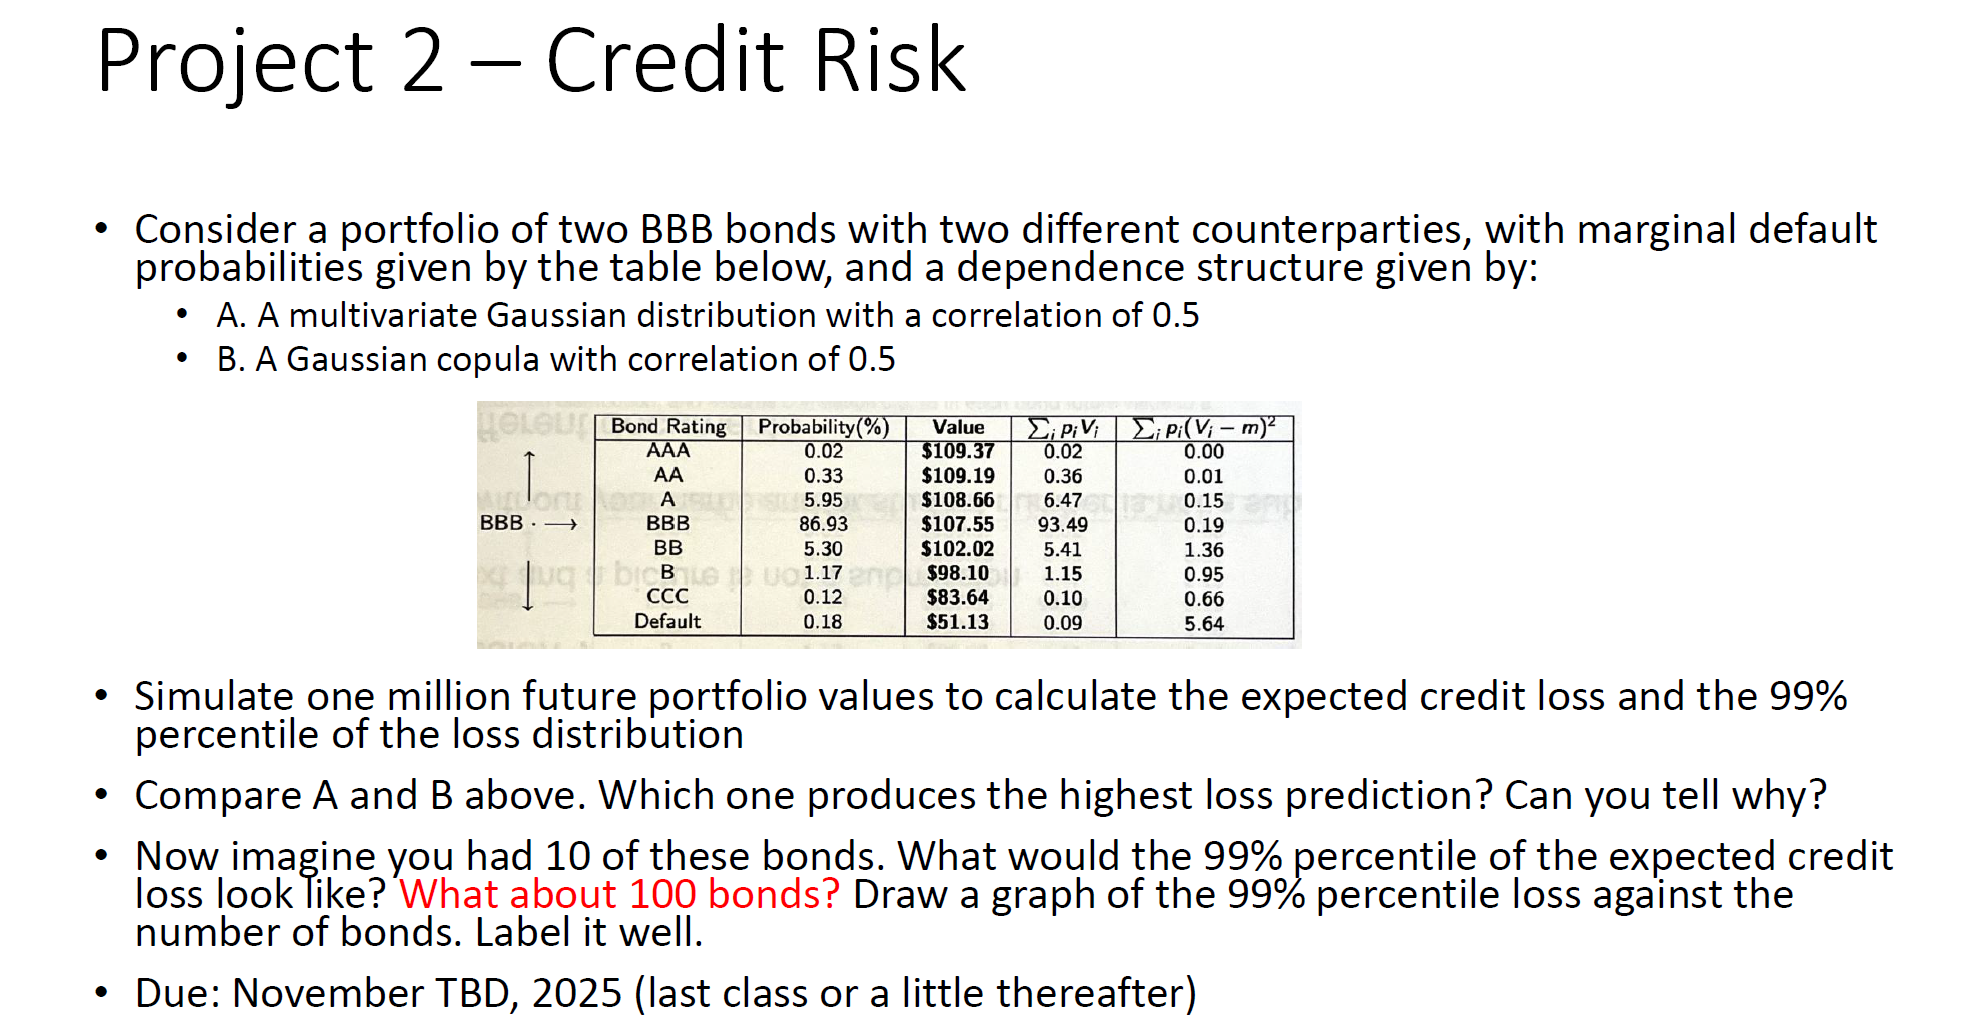

In [1]:
import pandas as pd
import numpy as np
import random
from scipy.stats import norm
from statsmodels.distributions.copula.api import GaussianCopula
import matplotlib.pyplot as plt

### Step1: Parameter Set Up

In [2]:
BondRating = ["AAA", "AA", "A", "BBB", "BB", "B", "C", "Default"]
Probability = [0.02, 0.33, 5.95, 86.93, 5.30, 1.17, 0.12, 0.18] 
Probability = [i/100 for i in Probability]
CumProbability = np.flip(np.cumsum(np.flip(Probability)) )
 
BondValue = [109.37, 109.19, 108.66, 107.55, 102.02, 98.10, 83.64, 51.13]

In [3]:
ZDefault = norm.ppf(Probability[7])                 
ZC       = norm.ppf(np.sum(Probability[6:8]))         
ZB       = norm.ppf(np.sum(Probability[5:8]))        
ZBB      = norm.ppf(np.sum(Probability[4:8]))        
ZBBB     = norm.ppf(np.sum(Probability[3:8]))       
ZA       = norm.ppf(np.sum(Probability[2:8]))         
ZAA      = norm.ppf(np.sum(Probability[1:8]))        
ZAAA     = norm.ppf(np.sum(Probability[0:8]))
ZBoundary = [ZAAA, ZAA, ZA, ZBBB, ZBB, ZB, ZC, ZDefault]

In [4]:
TblBond = pd.DataFrame()
TblBond['Rating'] = BondRating
TblBond['Probability'] = Probability
TblBond['CumProbability'] = CumProbability
TblBond['TrasitionValue'] = BondValue
TblBond['Z'] = ZBoundary

In [5]:
TblBond

,Rating,Probability,CumProbability,TrasitionValue,Z
0,AAA,0.0002,1.0000,109.37,inf
1,AA,0.0033,0.9998,109.19,3.540084
2,A,0.0595,0.9965,108.66,2.696844
3,BBB,0.8693,0.9370,107.55,1.530068
4,BB,0.0530,0.0677,102.02,-1.493142
5,B,0.0117,0.0147,98.10,-2.178081
6,C,0.0012,0.0030,83.64,-2.747781
7,Default,0.0018,0.0018,51.13,-2.911238


### Step2: Comparison in credit loss in multivariate gaussian and gaussian copula
Code Steps:
1. Generate Correlated Samples from a Copula
2. Estimate the Probability of Default

<br> Comparison Result:
The Gaussian Copula has 99% loss in 14.05 and the Multivariate Gaussian has the 99% loss in 8.53, so the gaussian copula provider larger loss prediction.

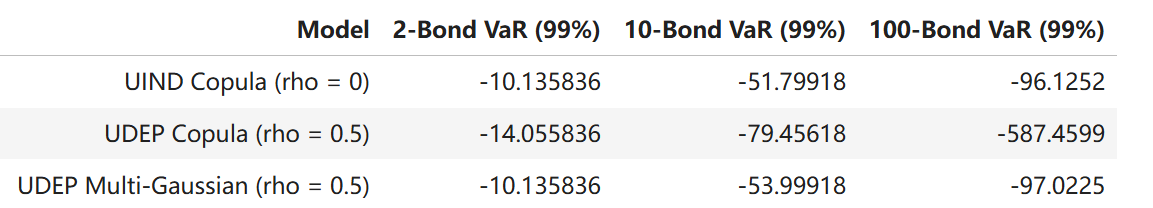

In [6]:
N = 100000
DefaultRho = 0.5

In [7]:
class GaussianBondPortfolio:
    """
    Simulate portfolio credit loss of K identical bonds using a
    multivariate Gaussian approximation with constant pairwise correlation.
    """

    def __init__(self, N, K, DefaultRho, TblBond, BondValue, var_loss_thr=0.99):

        ### Set Input Variables
        self.prob_percent = np.array(TblBond['Probability'])
        self.values = np.array(BondValue)
        self.TblBond = TblBond
        self.K = K
        self.N = N
        self.rho = DefaultRho
        self.var_loss_thr = var_loss_thr
        self.V0_bond = (TblBond['Probability'] * TblBond['TrasitionValue']).sum()
        self._build_moments()
        self.seed = 42
        
        ### Simulation
        self.loss_q, self.expected_loss, self.losses = self.simulate(return_losses=True)
        self.ES = self.expected_shortfall()

    def _build_moments(self):
        """Compute mean, variance, and covariance matrix for K bonds."""
        p = self.prob_percent 
        V = self.values

        self.m = np.sum(p * V)
        self.var = np.sum(p * (V - self.m) ** 2)
        Sigma = np.full((self.K, self.K), self.rho * self.var)
        np.fill_diagonal(Sigma, self.var)

        self.mu_vec = np.full(self.K, self.m)
        self.Sigma = Sigma

    def simulate(self, return_losses=False):
        """Simulate pnls & compute VaR."""
        
        # simulate K correlated bond values
        np.random.seed(self.seed)
        sims = np.random.multivariate_normal(self.mu_vec, self.Sigma, size=self.N)
        V_port = sims.sum(axis=1)
        V0_port = self.K * self.V0_bond

        # loss = positive = loss
        pnl =  V_port  -V0_port 

        expected_pnl = pnl.mean()
        pnl_q = np.quantile(pnl, 1-self.var_loss_thr)

        if return_losses:
            return pnl_q, expected_pnl, pnl
        else:
            return pnl_q, expected_pnl
        
    def expected_shortfall(self):
        
        pnl = self.losses ## it is return
        q = self.var_loss_thr
        pnl = np.asarray(pnl)
        var_q = np.quantile(pnl, 1-q)

        # losses beyond VaR
        tail_losses = pnl[pnl <= var_q]

        # ES = average of tail losses
        es_q = tail_losses.mean()

        return es_q

In [8]:
class simulate_Corpula:
    def __init__(self, N,K, DefaultRho,TblBond,  BondValue ):
        '''
        N: simulation times
        K: number of bonds in this portfolio
        '''
        self.N =N
        self.K =K
        self.DefaultRho  = DefaultRho 
        self.mu = [0,] * K
        self.TblBond = TblBond
        self.BondValue =  BondValue
        self.var_thre = 0.99
        
        ev_single = np.sum(TblBond['Probability'] * TblBond['TrasitionValue'])
        # Variance = E[X^2] - (E[X])^2 or sum(p * (x-mean)^2)
        var_single = np.sum(TblBond['Probability'] * (TblBond['TrasitionValue'] - ev_single)**2)
        self.std = np.sqrt(var_single)

        self.CIND = np.eye(self.K)
        self.CDEP = np.full((self.K, self.K), self.DefaultRho)
        np.fill_diagonal(self.CDEP, 1) 

        self.UIND_gaussian_copula  = self.ind_correlated_sample()
        self.UDEP_gaussian_copula = self.unind_correlated_sample()
                
        self.CurrentValueBond = self.TblBond['Probability'] * self.TblBond['TrasitionValue']
        self.CurrentValueBond = self.CurrentValueBond.sum()
        self.CumProbabilityBoundary = self.TblBond['CumProbability'].tolist()

        
        self.UIND_FutureBondValueDEP,self.UIND_pnl = self.calculate_portfolio_pnl(self.UIND_gaussian_copula)
        self.UDEP_FutureBondValueDEP_copula,self.UDEP_copula_pnl = self.calculate_portfolio_pnl(self.UDEP_gaussian_copula)
        self.var_ind, self.es_ind = self.VAR_expected_shortfall(self.UIND_pnl)
        self.var_dep, self.es_dep = self.VAR_expected_shortfall(self.UDEP_copula_pnl)

        
    def ind_correlated_sample(self):
        cop = GaussianCopula(corr=self.CIND)
        U = cop.rvs(self.N )
        return U 

    def unind_correlated_sample(self):
        cop = GaussianCopula(corr=self.CDEP)
        U = cop.rvs(self.N )
        return U 

    def calculate_portfolio_pnl(self, UDEP):            
        rev = self.CumProbabilityBoundary[::-1]
        FutureBondValueDEP = np.full((self.N, self.K), np.nan)
        
        for i in range(self.N):
            for k in range(self.K):
                IZ1 = len(rev) - np.searchsorted(rev, UDEP[i,k], side='left') - 1
                FutureBondValueDEP[i,k] = self.BondValue[min(IZ1,8)]

        PortfolioDEP = np.sum(FutureBondValueDEP , axis=1) - self.K * self.CurrentValueBond 
        return FutureBondValueDEP, PortfolioDEP
    
    
    def VAR_expected_shortfall(self, pnl):
        q = self.var_thre
        pnl = np.asarray(pnl)
        var_q = np.quantile(pnl, 1-q) ## Var

        # losses beyond VaR
        tail_losses = pnl[pnl <= var_q]

        # ES = average of tail losses
        es_q = tail_losses.mean()
        

        return var_q, es_q


In [9]:
### Multivariate Gaussian 
credit_loss_gaussian_2Bond = GaussianBondPortfolio(N,2, DefaultRho,TblBond,  BondValue, 0.99)
credit_loss_gaussian_10Bond = GaussianBondPortfolio(N,10, DefaultRho,TblBond,  BondValue, 0.99)
credit_loss_gaussian_100Bond = GaussianBondPortfolio(N,100, DefaultRho,TblBond,  BondValue, 0.99)

### Copula
two_bond_copula_portfolio = simulate_Corpula(N,2, DefaultRho,TblBond,BondValue)
ten_bond_copula_portfolio = simulate_Corpula(N,10, DefaultRho,TblBond,BondValue )
hundred_bond_copula_portfolio = simulate_Corpula(N,100, DefaultRho,TblBond ,BondValue)

### Step3: Expand the portfolio and see the credit loss distribution

In [10]:
### Gaussian
credit_loss_gaussian_2Bond_99var = credit_loss_gaussian_2Bond.loss_q
credit_loss_gaussian_10Bond_99var = credit_loss_gaussian_10Bond.loss_q
credit_loss_gaussian_100Bond_99var = credit_loss_gaussian_100Bond.loss_q

credit_loss_gaussian_2Bond_99ES = credit_loss_gaussian_2Bond.ES
credit_loss_gaussian_10Bond_99ES = credit_loss_gaussian_10Bond.ES
credit_loss_gaussian_100Bond_99ES = credit_loss_gaussian_100Bond.ES

### Copula VAR
UIND_copula_pnl_99var = two_bond_copula_portfolio.var_ind  
UIND_copula_pnl_99var_10bond = ten_bond_copula_portfolio.var_ind 
UIND_copula_pnl_99var_100bond = hundred_bond_copula_portfolio.var_ind 

UDEP_copula_pnl_99var = two_bond_copula_portfolio.var_dep  
UDEP_copula_pnl_99var_10bond = ten_bond_copula_portfolio.var_dep 
UDEP_copula_pnl_99var_100bond = hundred_bond_copula_portfolio.var_dep 

### Copula ES
UIND_copula_pnl_99es = two_bond_copula_portfolio.es_ind  
UIND_copula_pnl_99es_10bond = ten_bond_copula_portfolio.es_ind 
UIND_copula_pnl_99es_100bond = hundred_bond_copula_portfolio.es_ind 

UDEP_copula_pnl_99es = two_bond_copula_portfolio.es_dep  
UDEP_copula_pnl_99es_10bond = ten_bond_copula_portfolio.es_dep 
UDEP_copula_pnl_99es_100bond = hundred_bond_copula_portfolio.es_dep 

In [11]:
summary_99var = pd.DataFrame({
    "Model": ["UIND Copula (rho = 0)", "UDEP Copula (rho = 0.5)", "UDEP Multi-Gaussian  (rho = 0.5)",
              "UDEP Copula ES (rho = 0.5)",  "UDEP Multi-Gaussian ES (rho = 0.5)"],
    "2-Bond VaR (99%)": [
        UIND_copula_pnl_99var, UDEP_copula_pnl_99var, credit_loss_gaussian_2Bond_99var, UDEP_copula_pnl_99es, credit_loss_gaussian_2Bond_99ES
    ],
    "10-Bond VaR (99%)": [
        UIND_copula_pnl_99var_10bond,
        UDEP_copula_pnl_99var_10bond,
        credit_loss_gaussian_10Bond_99var, UDEP_copula_pnl_99es_10bond, credit_loss_gaussian_10Bond_99ES
    ],
    "100-Bond VaR (99%)": [
        UIND_copula_pnl_99var_100bond,
        UDEP_copula_pnl_99var_100bond,
        credit_loss_gaussian_100Bond_99var, UDEP_copula_pnl_99es_100bond, credit_loss_gaussian_100Bond_99ES
    ]
})

summary_99var

,Model,2-Bond VaR (99%),10-Bond VaR (99%),100-Bond VaR (99%)
0,UIND Copula (rho = 0),-10.135836,-51.799180,-96.132600
1,UDEP Copula (rho = 0.5),-14.055836,-72.309180,-576.881200
2,UDEP Multi-Gaussian (rho = 0.5),-12.105760,-51.706632,-494.617409
3,UDEP Copula ES (rho = 0.5),-30.462869,-110.338655,-929.472700
4,UDEP Multi-Gaussian ES (rho = 0.5),-13.775100,-59.111938,-568.268054


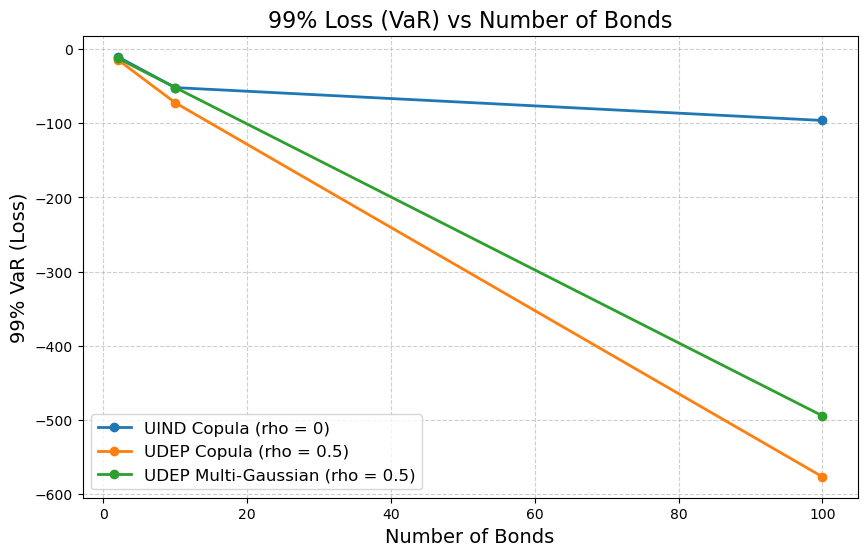

In [24]:
# Direct input from your table
num_bonds = [2, 10, 100]

UIND = summary_99var.iloc[0].tolist()[1:]
UDEP = summary_99var.iloc[1].tolist()[1:]
MultiG = summary_99var.iloc[2].tolist()[1:]
ES_copula = summary_99var.iloc[3].tolist()[1:]
ES_gaussian = summary_99var.iloc[4].tolist()[1:]

plt.figure(figsize=(10,6))

plt.plot(num_bonds, UIND, marker='o', linewidth=2, label='UIND Copula (rho = 0)')
plt.plot(num_bonds, UDEP, marker='o', linewidth=2, label='UDEP Copula (rho = 0.5)')
plt.plot(num_bonds, MultiG, marker='o', linewidth=2, label='UDEP Multi-Gaussian (rho = 0.5)')
#plt.plot(num_bonds, ES_copula, marker='o', linewidth=2, label='UDEP Expected Shortfall (rho = 0.5)')
#plt.plot(num_bonds, ES_gaussian, marker='o', linewidth=2, label='UDEP Multi-Gaussian ES (rho = 0.5)')


plt.title('99% Loss (VaR) vs Number of Bonds', fontsize=16)
plt.xlabel('Number of Bonds', fontsize=14)
plt.ylabel('99% VaR (Loss)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.show()

### Appendix

### Note From Options, Futures and Other Derivatives, John Hull.

Corpula:
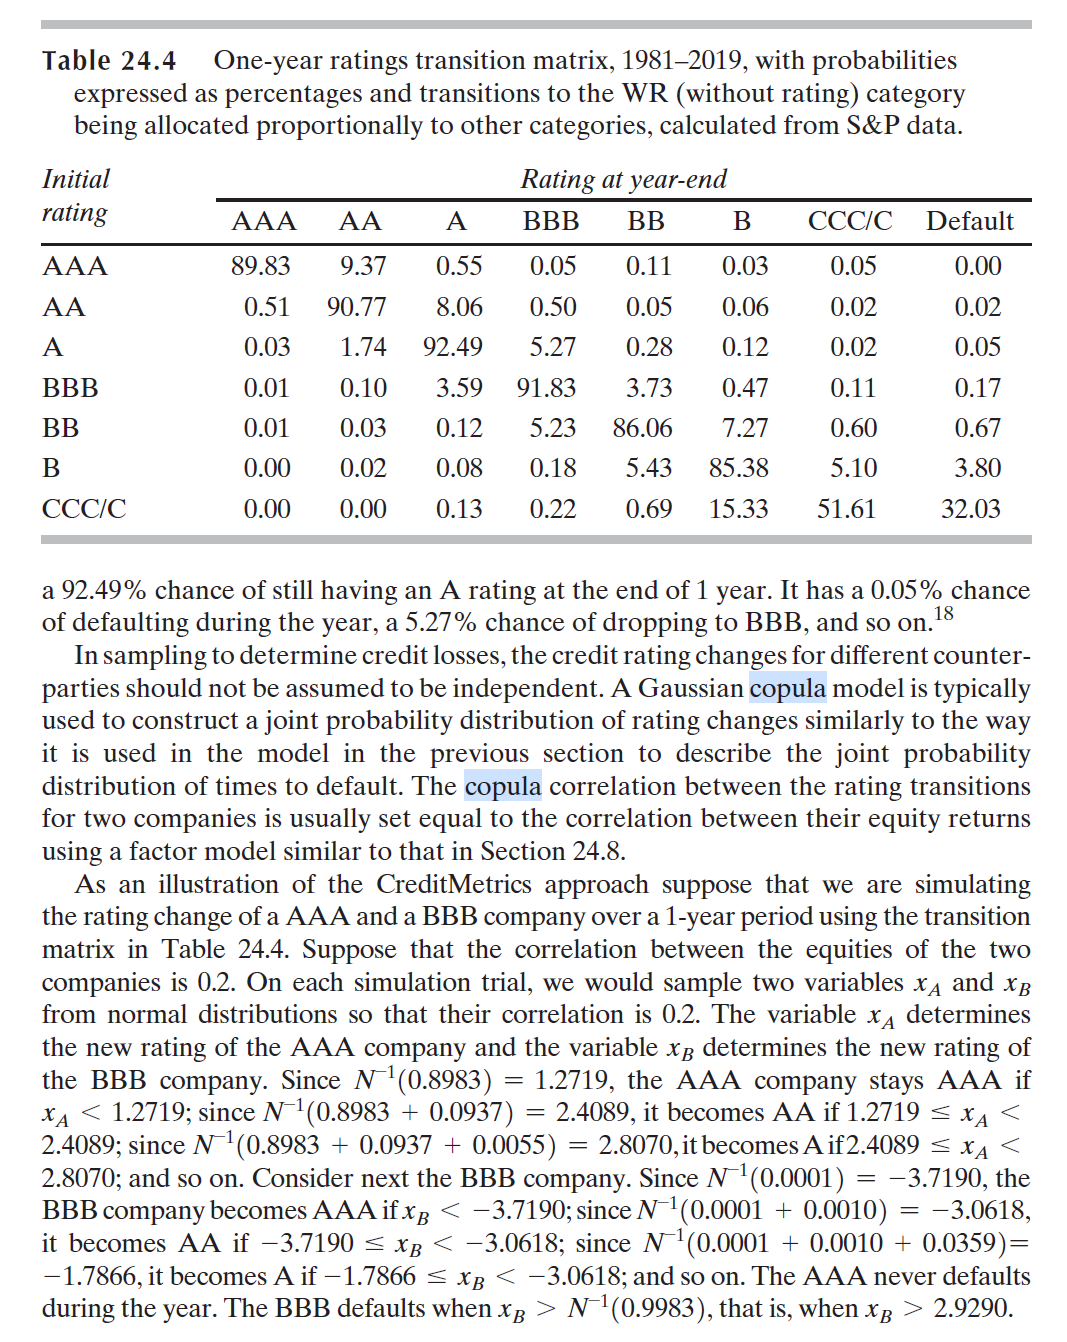